# Introduction to Band Structures

In condensed matter physics and materials science, the concept of *band structure* is fundamental to understanding the electronic properties of materials. The band structure describes the allowed energy levels of electrons within a solid, revealing how electrons can move through the material and respond to external stimuli, such as electric fields.

Band structures emerge from the periodic arrangement of atoms in a crystal lattice, which causes the electronic energy levels to split and form continuous energy bands. These bands are separated by energy gaps (forbidden regions), which play a crucial role in determining whether a material behaves as a conductor, semiconductor, or insulator. By examining the distribution and width of these bands, as well as the size of the energy gap, we can predict how electrons will contribute to properties like conductivity, optical absorption, and thermal behavior.

In a band structure calculation, typically performed using Density Functional Theory (DFT) or related quantum mechanical models, we calculate the energy of an electron as a function of its wavevector, \( \mathbf{k} \), within the Brillouin zone of the crystal. This relationship, \( E(\mathbf{k}) \), provides insights into the electronic dispersion, effective mass of electrons, and potential for electron mobility in the material.


In [ ]:
# Import necessary modules
from ase.build import bulk
from ase.optimize import BFGS
from gpaw import GPAW, PW, FermiDirac
import matplotlib.pyplot as plt

# Step 1: Create bulk gold unit cell
a = 4.08  # approximate lattice constant for gold in angstroms
gold = bulk('Au', 'fcc', a=a)

# Step 2: Set up GPAW calculator with LDA and a plane-wave basis
calc = GPAW(mode=PW(500),                # Plane-wave cutoff energy (500 eV is typical)
            xc='LDA',                    # Exchange-correlation functional
            kpts=(8, 8, 8),              # k-point grid for Brillouin zone sampling
            occupations=FermiDirac(0.1), # Smearing for metallic systems
            txt='gold_relaxation.txt')   # Output file for relaxation steps

gold.set_calculator(calc)

# Step 3: Relax the structure
relax = BFGS(gold, logfile='relaxation.log')
relax.run(fmax=0.01)  # Relax until forces are below 0.01 eV/Å

# Step 4: Perform a self-consistent ground-state calculation
calc.get_potential_energy()  # Finalize the self-consistent calculation
calc.write('gold_scf.gpw')   # Save the self-consistent calculation


In [ ]:
# Step 5: Band structure calculation with non-self-consistent run
# Restart from the saved self-consistent file for band structure
calc = GPAW('gold_scf.gpw').fixed_density(
    symmetry='off',
    kpts={'path': 'GXWLG', 'npoints': 60},
    txt='gold_bandstructure.txt'
    )

# Calculate and plot the band structure
bs = calc.band_structure()
bs.plot(filename='Au_bandstructure.png', show=True, emax=15.0,emin=0)  # Save band structure plot to a file


In [ ]:
# Step 6: Calculate the Density of States

# Extract DOS using the calculator's get_dos method
dos_energies, dos_values = calc.get_dos(npts=1000, width=0.1)  # Smearing of 0.1 eV

# Plot the Density of States
plt.figure()
plt.plot(dos_energies, dos_values, label='Density of States')

# Add a vertical line at the Fermi level
plt.axvline(x=calc.get_fermi_level(), color='red', linestyle='--', label='Fermi Level')

plt.axhline(y=0, color='k', linestyle='--',linewidth=1)
plt.xlabel('Energy (eV)')
plt.ylabel('DOS (states/eV)')
plt.legend()
plt.savefig('Au_dos.png')  # Save DOS plot to a file
plt.show()

# Key Features of a Metallic Band Structure


1. **Partially Filled Bands**: Unlike insulators or semiconductors, metals have electronic bands that are only partially filled, meaning the Fermi level intersects one or more energy bands. This allows electrons near the Fermi level to move freely under an electric field, contributing to electrical conductivity.


2. **No Band Gap**: Metals lack a band gap between the valence and conduction bands. Instead, the conduction band overlaps with the valence band or extends continuously across the Fermi level. This overlap ensures that electrons are always available for conduction, even at low temperatures.


3. **High Density of States at the Fermi Level**: Metals exhibit a high density of electronic states at the Fermi level, which means there are many available states for electrons to occupy. This characteristic supports high electron mobility and conductivity, as electrons can readily respond to external forces.


4. **Linear Dispersion near Fermi Level (in some metals)**: In certain metals (such as those with Dirac-like behavior), the band structure near the Fermi level displays linear dispersion. This indicates a lower effective mass for electrons, often resulting in high carrier mobility.

These features imply that metals are excellent conductors of electricity and heat, as electrons can easily transition between energy levels and move through the lattice with minimal energy input.


In [ ]:
from ase.build import bulk
from ase.optimize import BFGS
from gpaw import GPAW, PW, FermiDirac
import matplotlib.pyplot as plt

# Step 1: Set up bulk Si structure
si_bulk = bulk('Si', 'diamond', a=5.43)  # Silicon in a diamond cubic structure with lattice constant 5.43 Å

# Step 2: Set up GPAW calculator with LDA and a plane-wave basis
calc = GPAW(mode=PW(500),                # Plane-wave cutoff energy (500 eV is typical)
            xc='LDA',                    # Exchange-correlation functional
            kpts=(8, 8, 8),              # k-point grid for bulk Si
            occupations=FermiDirac(0.1), # Smearing for metallic systems
            txt='si_bulk_relaxation.txt')  # Output file for relaxation steps

si_bulk.set_calculator(calc)

# Step 3: Relax the structure
relax = BFGS(si_bulk, logfile='si_bulk_relaxation.log')
relax.run(fmax=0.01)  # Relax until forces are below 0.01 eV/Å

# Step 4: Perform a self-consistent ground-state calculation
calc.get_potential_energy()  # Finalize the self-consistent calculation
calc.write('si_bulk_scf.gpw')   # Save the self-consistent calculation


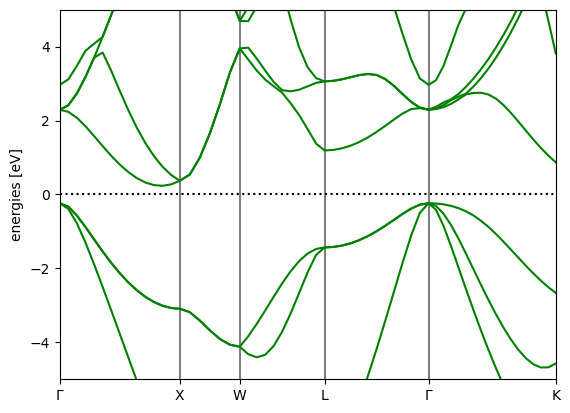

<Axes: ylabel='energies [eV]'>

In [13]:
# Step 5: Band structure calculation with non-self-consistent run
# Restart from the saved self-consistent file for band structure
calc = GPAW('si_bulk_scf.gpw').fixed_density(
    kpts={'path': 'GXWLGK', 'npoints': 60},  # High-symmetry path for bulk Si (indirect band gap)
    symmetry='off',                           # Turn off symmetry to access full path
    txt='si_bulk_bandstructure.txt'
)

# Calculate and plot the band structure
bs = calc.band_structure().subtract_reference()
bs.plot(filename='si_bulk_bandstructure.png',show=True, emax=5,emin=-5) 

In [14]:
calc.get_homo_lumo()

array([5.13756339, 5.61021309])

In [19]:
import numpy as np

# Get k-points along the path
k_points = calc.get_bz_k_points()

# Get the Fermi level
fermi_level = calc.get_fermi_level()

# Get all eigenvalues for each band and k-point
# Note: The shape will be (num_kpoints, num_bands)
eigenvalues = np.array([calc.get_eigenvalues(kpt=k) for k in range(len(k_points))])

# Initialize variables for tracking VBM and CBM
valence_band_max = -np.inf
conduction_band_min = np.inf
vbm_kpt = None
cbm_kpt = None

# Loop over each k-point and its corresponding band energies
for kpt_idx, bands in enumerate(eigenvalues):
    # Find the maximum energy below the Fermi level (VBM) for this k-point
    max_valence = max(e for e in bands if e < fermi_level)
    if max_valence > valence_band_max:
        valence_band_max = max_valence
        vbm_kpt = k_points[kpt_idx]  # Store the k-point coordinates of VBM

    # Find the minimum energy above the Fermi level (CBM) for this k-point
    min_conduction = min(e for e in bands if e > fermi_level)
    if min_conduction < conduction_band_min:
        conduction_band_min = min_conduction
        cbm_kpt = k_points[kpt_idx]  # Store the k-point coordinates of CBM

# Calculate the band gap
band_gap = conduction_band_min - valence_band_max
print(f"Valence Band Maximum (VBM): {valence_band_max:.3f} eV at k-point {vbm_kpt}")
print(f"Conduction Band Minimum (CBM): {conduction_band_min:.3f} eV at k-point {cbm_kpt}")
print(f"Band Gap: {band_gap:.3f} eV")

# Check if the band gap is direct or indirect
if np.allclose(vbm_kpt, cbm_kpt):
    print("The band gap is direct.", vbm_kpt)
else:
    print("The band gap is indirect.",vbm_kpt, cbm_kpt)


Valence Band Maximum (VBM): 5.138 eV at k-point [0. 0. 0.]
Conduction Band Minimum (CBM): 5.610 eV at k-point [0.42857143 0.         0.42857143]
Band Gap: 0.473 eV
The band gap is indirect. [0. 0. 0.] [0.42857143 0.         0.42857143]


# Key Features of a Semiconducting Band Structure

A semiconducting band structure has several defining characteristics that imply specific electronic properties:

1. **Finite Band Gap**: Semiconductors exhibit a finite band gap between the highest occupied (valence) band and the lowest unoccupied (conduction) band. This band gap typically ranges from about 0.1 to 3 eV, allowing control over electron flow through external excitation.


2. **Temperature-Dependent Conductivity**: At absolute zero, semiconductors act as insulators since there are no electrons in the conduction band. However, at higher temperatures or under light exposure, electrons can be thermally or optically excited across the band gap, allowing electrical conductivity. This temperature-dependent behavior is central to semiconductor functionality.


3. **Effective Mass of Charge Carriers**: The curvature of the bands near the edges of the conduction and valence bands influences the effective mass of electrons and holes. Lower effective masses allow easier mobility of charge carriers, enhancing conductivity.


4. **Direct vs. Indirect Band Gap**: Semiconductors can have a direct or indirect band gap. In direct band gap materials (e.g., GaAs), the highest valence band and lowest conduction band align in momentum space, enabling efficient light absorption and emission. In indirect band gap materials (e.g., Si), the conduction band minimum and valence band maximum occur at different momenta, making optical transitions less efficient.

These features imply that semiconductors can be precisely controlled for various electronic and optoelectronic applications, such as transistors, solar cells, and LEDs, where conductivity can be modulated by temperature, doping, or light.
